In [1]:
# TASK 2 - DEEP LEARNING PROJECT
# Intern: Vivek Dipak Kshirsagar | ID: CTIS6665
# Codtech IT Solutions | Data Science Internship

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

print("✅ All Libraries Imported Successfully!")
print("✅ TensorFlow Ready!")

✅ All Libraries Imported Successfully!
✅ TensorFlow Ready!


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
✅ Dataset Loaded!
Training Data: (60000, 28, 28)
Testing Data: (10000, 28, 28)


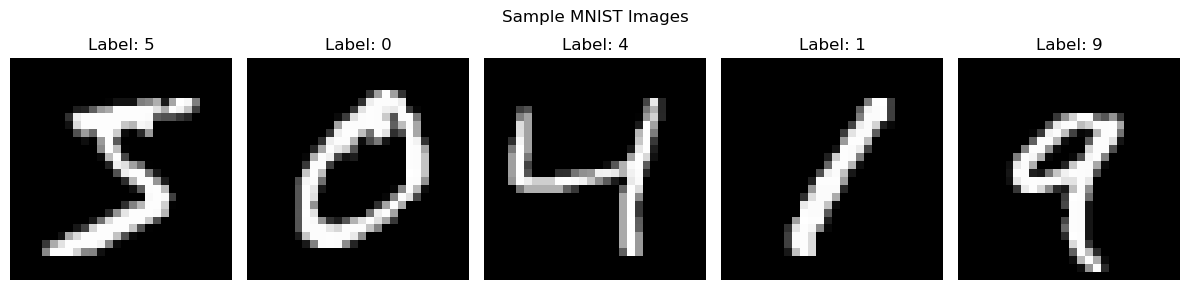

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"✅ Dataset Loaded!")
print(f"Training Data: {X_train.shape}")
print(f"Testing Data: {X_test.shape}")

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    axes[i].imshow(X_train[i], cmap='gray')
    axes[i].set_title(f'Label: {y_train[i]}')
    axes[i].axis('off')
plt.suptitle('Sample MNIST Images')
plt.tight_layout()
plt.show()

In [3]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("✅ Data Preprocessed!")
print(f"X_train shape: {X_train.shape}")

✅ Data Preprocessed!
X_train shape: (60000, 28, 28, 1)


In [4]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("✅ CNN Model Built!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

✅ CNN Model Built!


In [5]:
history = model.fit(
    X_train, y_train_cat,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

print("✅ Model Training Complete!")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.8983 - loss: 0.3361 - val_accuracy: 0.9803 - val_loss: 0.0706
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.9684 - loss: 0.1087 - val_accuracy: 0.9870 - val_loss: 0.0480
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.9760 - loss: 0.0781 - val_accuracy: 0.9870 - val_loss: 0.0419
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.9811 - loss: 0.0637 - val_accuracy: 0.9900 - val_loss: 0.0368
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.9840 - loss: 0.0541 - val_accuracy: 0.9888 - val_loss: 0.0373
✅ Model Training Complete!


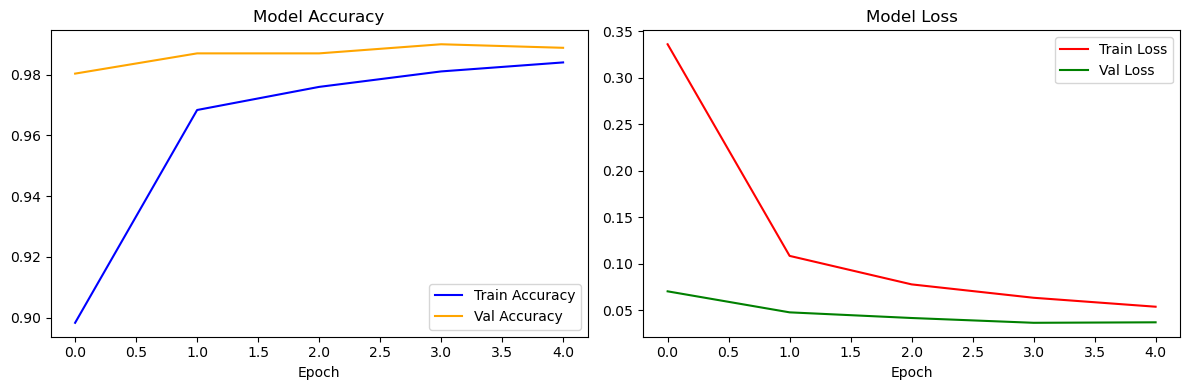

✅ Visualizations Done!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss', color='red')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='green')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('task2_results.png')
plt.show()
print("✅ Visualizations Done!")

Test Accuracy: 98.94%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step


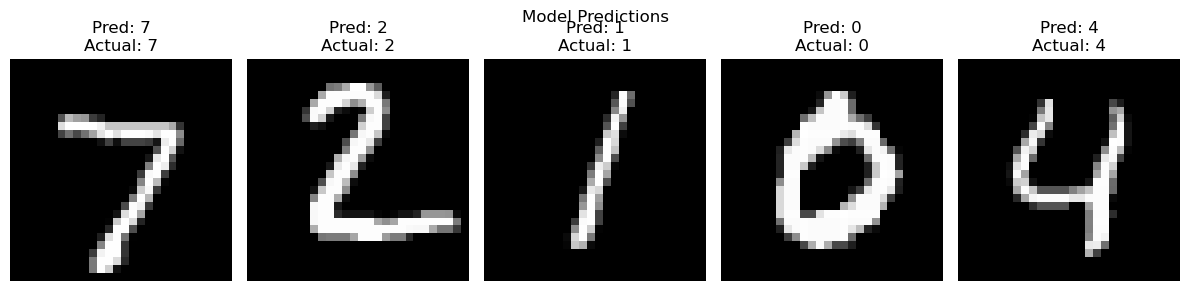

TASK 2 - DEEP LEARNING COMPLETE!
Model: CNN
Dataset: MNIST
Test Accuracy: 98.94%
Intern: Vivek Dipak Kshirsagar | CTIS6665


In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

predictions = model.predict(X_test[:5])

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    axes[i].imshow(X_test[i].reshape(28,28), cmap='gray')
    axes[i].set_title(f'Pred: {np.argmax(predictions[i])}\nActual: {y_test[i]}')
    axes[i].axis('off')
plt.suptitle('Model Predictions')
plt.tight_layout()
plt.show()

print("="*50)
print("TASK 2 - DEEP LEARNING COMPLETE!")
print("="*50)
print(f"Model: CNN")
print(f"Dataset: MNIST")
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print("Intern: Vivek Dipak Kshirsagar | CTIS6665")